In [199]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

In [10]:
titanic = sns.load_dataset("titanic")
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [11]:
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## What was the survival rate overall?

In [19]:
# Survival rate
survival_mean = titanic["survived"].mean()
survival_rate = survival_mean * 100
print(f"Survival_rate: {round(survival_rate,2)}%")

survival_rate: 38.38%


C:\Users\aaron\AppData\Local\Temp\ipykernel_25360\3800572299.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  survival.set_xticklabels(["Did not survive", "Survived"])


[Text(0, 0, 'Did not survive'), Text(1, 0, 'Survived')]

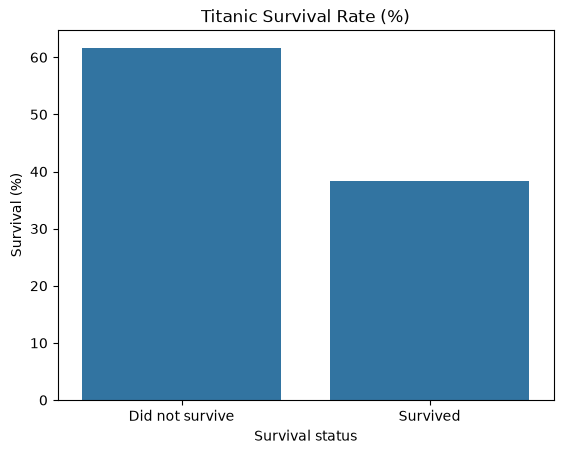

In [201]:
survival = sns.countplot(data=titanic, x="survived", stat="percent")
survival.set_xlabel("Survival status")
survival.set_ylabel("Survival (%)")
survival.set_title("Titanic Survival Rate (%)")
survival.set_xticklabels(["Did not survive", "Survived"])

## Did survival depend on sex?

In [120]:
sex_survival_rate = (titanic.groupby("sex")["survived"].mean()*100).reset_index()
sex_survival_rate
print(round(sex_survival_rate,2))
print("Female survival rate: 74.2%")
print("Male survival rate: 18.89%")

      sex  survived
0  female     74.20
1    male     18.89
Female survival rate: 74.2%
Male survival rate: 18.89%


C:\Users\aaron\AppData\Local\Temp\ipykernel_25360\1494122065.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  survival_sex.set_xticklabels(["Male", "Female"])


[Text(0, 0, 'Male'), Text(1, 0, 'Female')]

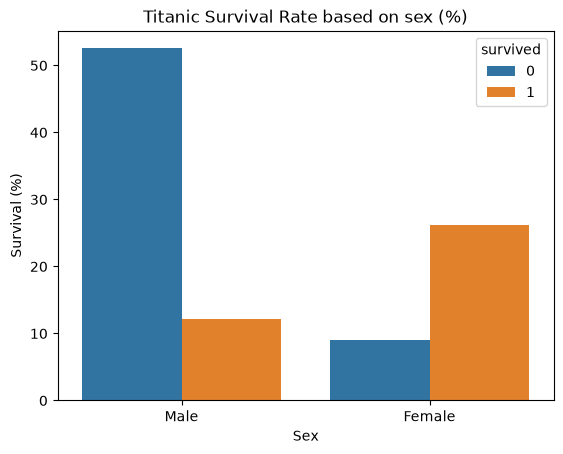

In [76]:
survival_sex = sns.countplot(data=titanic, x="sex", hue="survived", stat="percent")
survival_sex.set_xlabel("Sex")
survival_sex.set_ylabel("Survival (%)")
survival_sex.set_title("Titanic Survival Rate based on sex (%)")
survival_sex.set_xticklabels(["Male", "Female"])

## How did class affect survival?

In [126]:
class_survival_rate = (titanic.groupby("class")["survived"].mean()*100).reset_index()
print(round(class_survival_rate,2))
print("First class survival rate: 62.96%")
print("Second class survival rate: 47.28%")
print("Third class survival rate: 24.24%")

    class  survived
0   First     62.96
1  Second     47.28
2   Third     24.24
First class survival rate: 62.96%
Second class survival rate: 47.28%
Third class survival rate: 24.24%


Text(0.5, 1.0, 'Titanic Survival Rate based on class (%)')

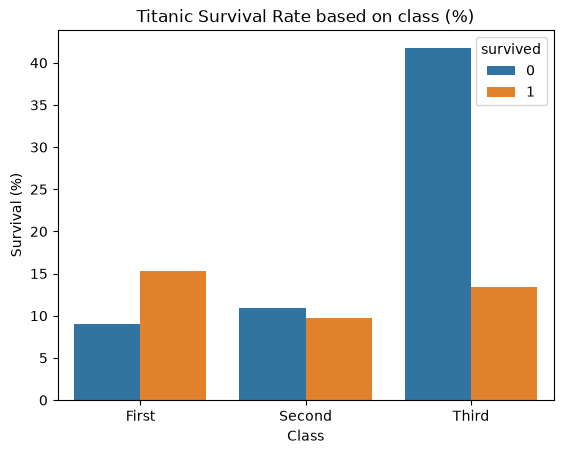

In [79]:
survival_class = sns.countplot(data=titanic, x="class", hue="survived", stat="percent")
survival_class.set_xlabel("Class")
survival_class.set_ylabel("Survival (%)")
survival_class.set_title("Titanic Survival Rate based on class (%)")

In [108]:
class_sex_survival = ((titanic.groupby(["class", "sex"])["survived"].mean()*100).reset_index())
class_sex_survival

,class,sex,survived
0,First,female,96.808511
1,First,male,36.885246
2,Second,female,92.105263
3,Second,male,15.740741
4,Third,female,50.000000
5,Third,male,13.544669


Text(0.5, 1.0, 'Titanic survival rates based on class and sex (%)')

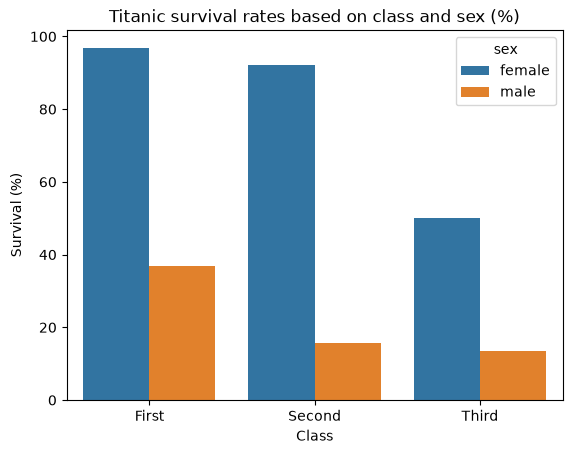

In [139]:
survival_class_sex = sns.barplot(data=class_sex_survival, x="class", y="survived", hue="sex")
survival_class_sex.set_ylabel("Survival (%)")
survival_class_sex.set_xlabel("Class")
survival_class_sex.set_title("Titanic survival rates based on class and sex (%)")

## What’s the relationship between age and survival?

In [129]:
titanic["age"].isnull().sum()

np.int64(177)

In [134]:
titanic["survived"].isnull().sum()

np.int64(0)

In [133]:
titanic["age"]=titanic["age"].fillna(titanic["age"].median())
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,28.0,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [193]:
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80]
lab = ["0-10", "10-20", "20-30", "30-40", "40-50", "50-60", "60-70", "70-80"]
titanic["age_group"] = pd.cut(titanic["age"],bins,lab)

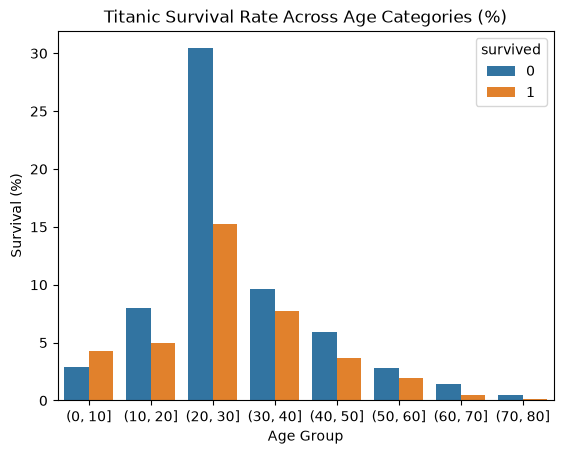

In [194]:
survival_age= sns.countplot(data=titanic, x="age_group", hue="survived", stat="percent")
survival_age.set_xlabel("Age Group")
survival_age.set_ylabel("Survival (%)")
survival_age.set_title("Titanic Survival Rate Across Age Categories (%)")
titanic["age_group"] = titanic["age_group"].cat.rename_categories(["0-10", "10-20", "20-30", "30-40", "40-50", "50-60", "60-70", "70-80"])

## How do sex, class, and age interact?

In [195]:
survival_rates = titanic.groupby(["age_group","sex","class"])["survived"].mean().reset_index()
survival_rates

,age_group,sex,class,survived
0,0-10,female,First,0.000000
1,0-10,female,Second,1.000000
2,0-10,female,Third,0.500000
3,0-10,male,First,1.000000
4,0-10,male,Second,1.000000
5,0-10,male,Third,0.363636
6,10-20,female,First,1.000000
7,10-20,female,Second,1.000000
8,10-20,female,Third,0.520000
9,10-20,male,First,0.400000


Text(0.5, 1.02, 'Titanic Survival by Age Category, Sex, and Class')

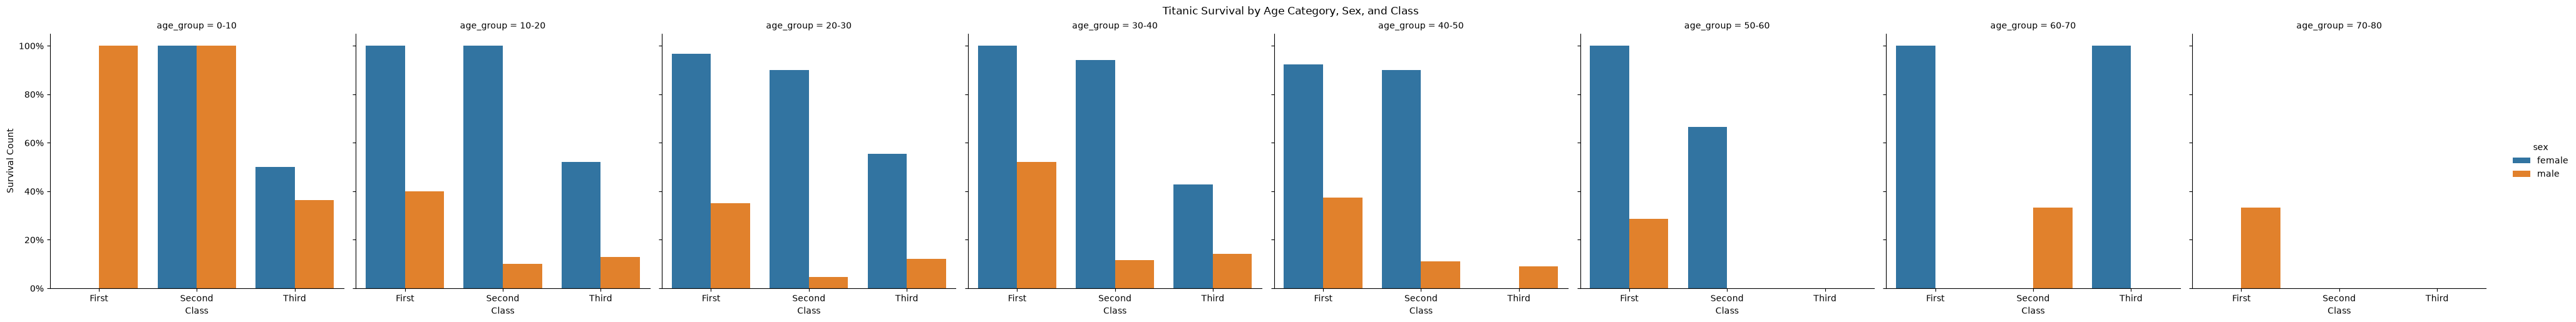

In [225]:
chart = sns.catplot(data=survival_rates, x="class", y="survived", hue="sex", col="age_group", kind="bar")
for ax in chart.axes.flat:
    ax.yaxis.set_major_formatter(PercentFormatter(1))
chart.set_axis_labels("Class", "Survival Count")
chart.fig.suptitle("Titanic Survival by Age Category, Sex, and Class", y=1.02)